# Testing, Evaluation, and Model Selection

In [ ]:
from __future__ import annotations

from datetime import datetime
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

SEED = 178
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
ROOT = Path.cwd().parent.parent
TRAIN_DIR = ROOT / "data" / "cifar10" / "train"
TEST_DIR = ROOT / "data" / "cifar10" / "test"
WEIGHTS_DIR = ROOT / "outputs" / "model_weights"
TEST_GRAPH_DIR = ROOT / "outputs" / "graphs" / "test"
RESULTS_PATH = ROOT / "results" / "shahpk1_cnn_final_results.md"
TEST_GRAPH_DIR.mkdir(parents=True, exist_ok=True)


def make_eval_transform() -> transforms.Compose:
    return transforms.Compose(
        [
            transforms.Resize((32, 32)),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
        ]
    )


def stratified_split_indices(
    targets: list[int], val_fraction: float = 0.25, seed: int = 178
) -> tuple[list[int], list[int]]:
    rng = np.random.default_rng(seed)
    y = np.array(targets)
    train_idx: list[int] = []
    val_idx: list[int] = []

    for class_id in np.unique(y):
        idx = np.where(y == class_id)[0]
        rng.shuffle(idx)
        n_val = int(len(idx) * val_fraction)
        val_idx.extend(idx[:n_val].tolist())
        train_idx.extend(idx[n_val:].tolist())

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return train_idx, val_idx


def make_val_test_loaders(
    batch_size: int = 128,
) -> tuple[DataLoader, DataLoader, list[str]]:
    eval_tf = make_eval_transform()
    train_ds = datasets.ImageFolder(str(TRAIN_DIR), transform=eval_tf)
    test_ds = datasets.ImageFolder(str(TEST_DIR), transform=eval_tf)

    _, val_idx = stratified_split_indices(
        train_ds.targets, val_fraction=0.25, seed=SEED
    )
    val_ds = Subset(train_ds, val_idx)

    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
    )
    return val_loader, test_loader, train_ds.classes


class ModelA(nn.Module):
    def __init__(self, num_classes: int = 10, dropout: float = 0.5) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 48, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(48, 48, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),
            nn.Conv2d(48, 96, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(96, 96, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(96 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


class AllCNNB(nn.Module):
    def __init__(self, num_classes: int = 10, dropout: float = 0.5) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Dropout2d(0.2),
            nn.Conv2d(3, 96, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(96, 96, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(96, 96, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Dropout(dropout),
            nn.Conv2d(96, 192, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(192, 192, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(192, 192, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Dropout(dropout),
            nn.Conv2d(192, 192, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(192, 192, kernel_size=1),
            nn.ReLU(True),
            nn.Conv2d(192, num_classes, kernel_size=1),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return x.view(x.size(0), -1)


class AllCNNC(nn.Module):
    def __init__(self, num_classes: int = 10, dropout: float = 0.5) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Dropout(0.2),
            nn.Conv2d(3, 96, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(96, 96, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(96, 96, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv2d(96, 192, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(192, 192, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(192, 192, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv2d(192, 192, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(192, 192, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(192, num_classes, kernel_size=1),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return x.view(x.size(0), -1)


def create_model(model_label: str) -> nn.Module:
    if model_label == "ModelA":
        return ModelA()
    if model_label == "AllCNNB":
        return AllCNNB()
    if model_label == "AllCNNC":
        return AllCNNC()
    raise ValueError(f"Unknown model label: {model_label}")


def evaluate_model(
    model: nn.Module, loader: DataLoader
) -> tuple[dict, list[int], list[int]]:
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            logits = model(images)
            preds = logits.argmax(dim=1)
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    metrics = {
        "accuracy": float(acc),
        "precision_macro": float(prec),
        "recall_macro": float(rec),
        "f1_macro": float(f1),
    }
    return metrics, y_true, y_pred


print(f"Setup complete. Device: {DEVICE}")
print(f"Plots will be saved under: {TEST_GRAPH_DIR}")

Setup complete. Device: cuda:0
Plots will be saved under: /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/outputs/graphs/test


,model,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,weights
0,AllCNNB,0.8086,0.8169,0.8086,0.8096,0.8113,0.8186,0.8113,0.8122,outputs/model_weights/shahpk1_allcnnb_weights.pt
1,AllCNNC,0.7299,0.7404,0.7299,0.7302,0.7276,0.7362,0.7276,0.7271,outputs/model_weights/shahpk1_allcnnc_weights.pt
2,ModelA,0.7234,0.7236,0.7234,0.7193,0.7185,0.7204,0.7185,0.7139,outputs/model_weights/shahpk1_modela_weights.pt


Selected best model from validation: AllCNNB
Saved table: /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/outputs/graphs/test/shahpk1_test_benchmark_table.csv


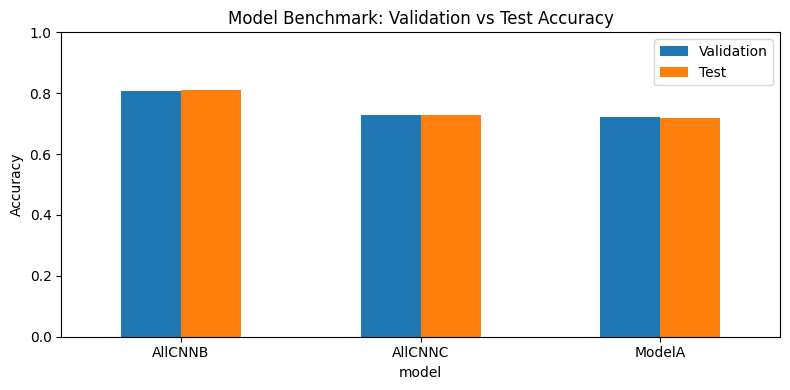

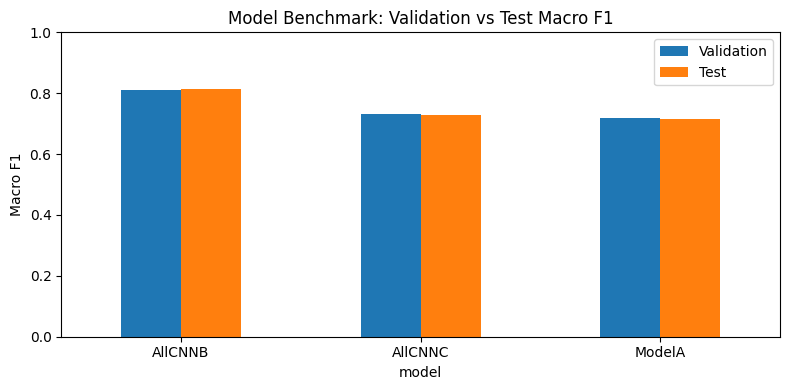

Saved: /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/outputs/graphs/test/shahpk1_test_confusion_matrix_modela.png
Saved: /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/outputs/graphs/test/shahpk1_test_confusion_matrix_allcnnb.png
Saved: /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/outputs/graphs/test/shahpk1_test_confusion_matrix_allcnnc.png
Saved: /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/outputs/graphs/test/shahpk1_test_accuracy_benchmark.png
Saved: /home/pronsh/Coding/CS178/third_party/CS178-goop-squad-CIFAR10/outputs/graphs/test/shahpk1_test_f1_benchmark.png


In [ ]:
val_loader, test_loader, class_names = make_val_test_loaders(batch_size=128)

model_specs = {
    "ModelA": WEIGHTS_DIR / "shahpk1_modela_weights.pt",
    "AllCNNB": WEIGHTS_DIR / "shahpk1_allcnnb_weights.pt",
    "AllCNNC": WEIGHTS_DIR / "shahpk1_allcnnc_weights.pt",
}

rows = []
test_predictions: dict[str, tuple[list[int], list[int]]] = {}

for model_label, weight_path in model_specs.items():
    model = create_model(model_label).to(DEVICE)
    state_dict = torch.load(weight_path, map_location=DEVICE)
    model.load_state_dict(state_dict, strict=True)

    val_metrics, _, _ = evaluate_model(model, val_loader)
    test_metrics, y_true_test, y_pred_test = evaluate_model(model, test_loader)
    test_predictions[model_label] = (y_true_test, y_pred_test)

    rows.append(
        {
            "model": model_label,
            "val_accuracy": round(val_metrics["accuracy"], 4),
            "val_precision_macro": round(val_metrics["precision_macro"], 4),
            "val_recall_macro": round(val_metrics["recall_macro"], 4),
            "val_f1_macro": round(val_metrics["f1_macro"], 4),
            "test_accuracy": round(test_metrics["accuracy"], 4),
            "test_precision_macro": round(test_metrics["precision_macro"], 4),
            "test_recall_macro": round(test_metrics["recall_macro"], 4),
            "test_f1_macro": round(test_metrics["f1_macro"], 4),
            "weights": str(weight_path.relative_to(ROOT)),
        }
    )

results_df = (
    pd.DataFrame(rows)
    .sort_values("val_accuracy", ascending=False)
    .reset_index(drop=True)
)
best_model_name = results_df.loc[0, "model"]

display(results_df)
print(f"Selected best model from validation: {best_model_name}")

benchmark_csv = TEST_GRAPH_DIR / "shahpk1_test_benchmark_table.csv"
results_df.to_csv(benchmark_csv, index=False)
print(f"Saved table: {benchmark_csv}")

plot_df = results_df.set_index("model")

ax = plot_df[["val_accuracy", "test_accuracy"]].plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Model Benchmark: Validation vs Test Accuracy")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.legend(["Validation", "Test"])
plt.tight_layout()
benchmark_acc_plot = TEST_GRAPH_DIR / "shahpk1_test_accuracy_benchmark.png"
plt.savefig(benchmark_acc_plot, dpi=160)
plt.show()
plt.close()

ax = plot_df[["val_f1_macro", "test_f1_macro"]].plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Model Benchmark: Validation vs Test Macro F1")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)
ax.legend(["Validation", "Test"])
plt.tight_layout()
benchmark_f1_plot = TEST_GRAPH_DIR / "shahpk1_test_f1_benchmark.png"
plt.savefig(benchmark_f1_plot, dpi=160)
plt.show()
plt.close()

for model_label, (y_true_test, y_pred_test) in test_predictions.items():
    cm = confusion_matrix(y_true_test, y_pred_test)
    plt.figure(figsize=(8, 7))
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(range(len(class_names)), class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Test Confusion Matrix - {model_label}")
    plt.tight_layout()
    cm_plot = (
        TEST_GRAPH_DIR / f"shahpk1_test_confusion_matrix_{model_label.lower()}.png"
    )
    plt.savefig(cm_plot, dpi=160)
    plt.close()
    print(f"Saved: {cm_plot}")

print(f"Saved: {benchmark_acc_plot}")
print(f"Saved: {benchmark_f1_plot}")